# step 5 classification - diagnosis of inter-coder-reliability agreement

In [ ]:
# pip installs:


#imports:

##imports for reading data
import json

#imports for word counts
import json
from pathlib import Path

##imports for plots
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
import numpy as np


# ─── PROJECT ROOT ─────────────────────────────────────────────────────────────
# Notebook lives at policy-tracker/3_classification — root is 1 levels up.
# All file paths below are built from PROJECT_ROOT; only filenames need to change.
PROJECT_ROOT = Path().resolve().parents[0]


In [7]:
#load data

file_path = PROJECT_ROOT / "data/classifications/germany/2026-04-27_intercoder_reliability_sb_vs_gpt-4.1-mini.json"

with open(file_path, "r", encoding="utf-8") as file:
    data = json.load(file)

entries = data if isinstance(data, list) else list(data.values())
for i, entry in enumerate(entries[:70]):
    print(f"--- Entry {i+1} ---")
    print(json.dumps(entry, ensure_ascii=False, indent=2))




--- Entry 1 ---
"2026-04-27"
--- Entry 2 ---
[
  "krippendorff_alpha",
  "cohen_kappa"
]
--- Entry 3 ---
[
  {
    "dataset_id": "germany_cov_gs_sb",
    "coder": "sb",
    "format": "gs",
    "path": "s:\\stbuchho\\crises_and_welfare_states\\policy-tracker\\data\\gold_standard\\germany_cov_sample_20_labelled_sb.json",
    "source_metadata": {
      "format": "gs",
      "path": "s:\\stbuchho\\crises_and_welfare_states\\policy-tracker\\data\\gold_standard\\germany_cov_sample_20_labelled_sb.json"
    }
  },
  {
    "dataset_id": "germany_cov_llm_gpt41mini_v1_zeroshot",
    "coder": "gpt-4.1-mini",
    "format": "llm",
    "path": "s:\\stbuchho\\crises_and_welfare_states\\policy-tracker\\data\\gold_standard\\2026-04-26_germany_cov_sample_20_llm_gpt-4.1-mini_v1_zero_shot.json",
    "source_metadata": {
      "format": "llm",
      "path": "s:\\stbuchho\\crises_and_welfare_states\\policy-tracker\\data\\gold_standard\\2026-04-26_germany_cov_sample_20_llm_gpt-4.1-mini_v1_zero_shot.json",
   

## `social_policy_field_1` — confusion matrix (human vs. LLM)

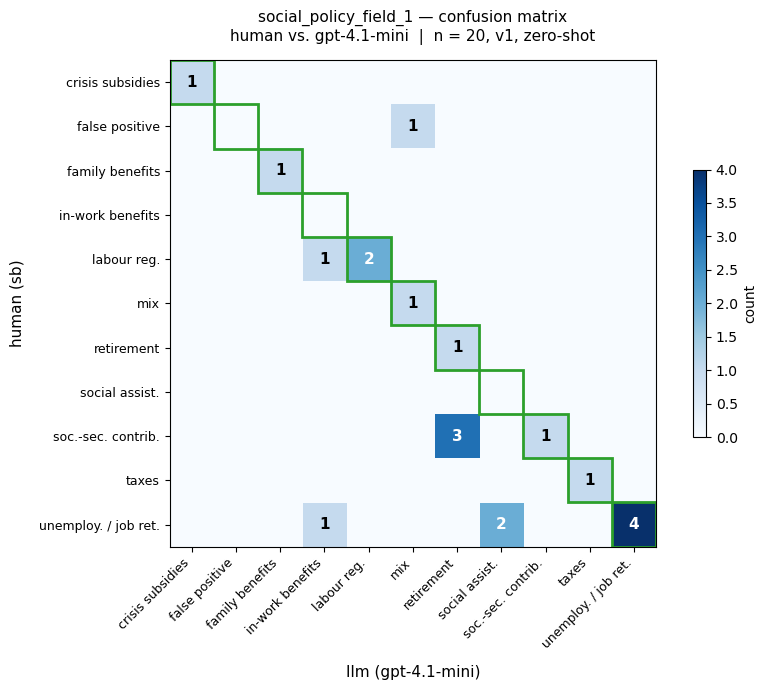

Agreements : 12/20  (60%)
Mismatches : 8/20

Off-diagonal entries (human → LLM):
  'false positive'                →  'mix'  (n=1)
  'labour reg.'                   →  'in-work benefits'  (n=1)
  'soc.-sec. contrib.'            →  'retirement'  (n=3)
  'unemploy. / job ret.'          →  'in-work benefits'  (n=1)
  'unemploy. / job ret.'          →  'social assist.'  (n=2)


In [11]:


# ── extract per-entry labels ───────────────────────────────────────────────────
per_entry = data["variable_results"]["social_policy_field_1"]["per_entry"]

human_labels = [e["values"]["sb"]            for e in per_entry]
llm_labels   = [e["values"]["gpt-4.1-mini"]  for e in per_entry]

# ── build confusion matrix (rows = human / ground truth, cols = LLM) ──────────
categories = sorted(set(human_labels) | set(llm_labels))
cat_idx    = {c: i for i, c in enumerate(categories)}
n          = len(categories)

matrix = np.zeros((n, n), dtype=int)
for h, l in zip(human_labels, llm_labels):
    matrix[cat_idx[h], cat_idx[l]] += 1

# ── short tick labels ──────────────────────────────────────────────────────────
SHORT = {
    "crisis-induced one-time subsidies":      "crisis subsidies",
    "false positive":                          "false positive",
    "in-work / employ-conditional benefits":   "in-work benefits",
    "labour regulation":                       "labour reg.",
    "mix":                                     "mix",
    "retirement benefits":                     "retirement",
    "social assistance and housing benefits":  "social assist.",
    "social-security contributions":           "soc.-sec. contrib.",
    "taxes":                                   "taxes",
    "unemploy benefits / job retention / activation": "unemploy. / job ret.",
    "family benefits":                         "family benefits",
    "sickness benefits":                       "sickness benefits",
}
tick_labels = [SHORT.get(c, c) for c in categories]

# ── plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=max(matrix.max(), 3))

# cell annotations
for i in range(n):
    for j in range(n):
        val = matrix[i, j]
        if val > 0:
            color = "white" if val >= 2 else "black"
            ax.text(j, i, str(val), ha="center", va="center",
                    fontsize=11, fontweight="bold", color=color)

# green border on diagonal (agreements)
for k in range(n):
    ax.add_patch(plt.Rectangle((k - 0.5, k - 0.5), 1, 1,
                                fill=False, edgecolor="#2ca02c", lw=2))

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(tick_labels, fontsize=9)
ax.set_xlabel("llm (gpt-4.1-mini)", fontsize=11, labelpad=10)
ax.set_ylabel("human (sb)", fontsize=11, labelpad=10)
ax.set_title(
    "social_policy_field_1 — confusion matrix\n"
    "human vs. gpt-4.1-mini  |  n = 20, v1, zero-shot",
    fontsize=11, pad=14,
)
plt.colorbar(im, ax=ax, shrink=0.55, label="count")
plt.tight_layout()
plt.show()

# ── text summary ───────────────────────────────────────────────────────────────
n_agree = int(sum(matrix[i, i] for i in range(n)))
print(f"Agreements : {n_agree}/20  ({n_agree/20:.0%})")
print(f"Mismatches : {20 - n_agree}/20\n")
print("Off-diagonal entries (human → LLM):")
for i, h in enumerate(categories):
    for j, l in enumerate(categories):
        if i != j and matrix[i, j] > 0:
            print(f"  {SHORT.get(h, h)!r:30s}  →  {SHORT.get(l, l)!r}  (n={matrix[i, j]})")